# Lending Club Project


---


**Importing Necessary Libraries**

In [ ]:
# Libraries for reading and manipulating data
import pandas as pd
import numpy as np

# libaries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library to split data into testing and training subsets
from sklearn.model_selection import train_test_split

# Libaries for model building and prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# GridSearchCV for tuning different models
from sklearn.model_selection import GridSearchCV


# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Loading Cleaned Data Again to Fix Loan Status

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/LendingClub_Cleaned_Ready.csv')

In [ ]:
df.columns

Index(['loan_amnt', 'int_rate', 'grade', 'issue_d', 'loan_status', 'dti',
       'fico_range_low', 'term_months', 'is_bad'],
      dtype='object')

In [ ]:
# 1. Isolate the finished loans from your big 2.9M row dataframe
finished_statuses = ['Fully Paid', 'Charged Off', 'Default', 'Does not meet the credit policy. Status:Fully Paid', 'Does not meet the credit policy. Status:Charged Off']
df_finished = df[df['loan_status'].isin(finished_statuses)].copy()

# 2. Add the is_bad flag specifically for this group
df_finished['is_bad'] = df_finished['loan_status'].apply(lambda x: 1 if 'Charged Off' in x or 'Default' in x else 0)

# Ensure 'issue_d' is datetime type and extract year
df_finished['issue_d'] = pd.to_datetime(df_finished['issue_d'], format='%Y-%m-%d', errors='coerce')
df_finished['issue_year'] = df_finished['issue_d'].dt.year

# Create 'size_category'
df_finished['size_category'] = df_finished['loan_amnt'].apply(lambda x: 'Whale (30k+)' if x >= 30000 else 'Standard (<30k)')

# Create 'fico_bucket'
df_finished['fico_bucket'] = pd.cut(df_finished['fico_range_low'],
                                    bins=[0, 660, 700, 750, 900],
                                    labels=['Subprime', 'Near-Prime', 'Prime', 'Super-Prime'])


# 3. Re-run the GroupBy to create the PBI Summary
pbi_true_yield = df_finished.groupby(['grade', 'term_months', 'issue_year', 'size_category', 'fico_bucket']).agg({
    'loan_amnt': ['count', 'sum'],
    'int_rate': 'mean',
    'is_bad': 'mean',
    'dti': 'mean'
}).reset_index()

pbi_true_yield.columns = ['Grade', 'Term', 'Year', 'Size', 'FICO_Bucket', 'Loan_Count', 'Total_Volume', 'Avg_Int_Rate', 'Default_Rate', 'Avg_DTI']

# 4. Save to Drive
pbi_true_yield.to_csv('/content/drive/My Drive/LendingClub_TRUE_YIELD.csv', index=False)


**Importing the Data**

### Load Cleaned Data

In [ ]:
#load cleaned version of the data
file_path = '/content/drive/MyDrive/LendingClub_Cleaned_Ready.csv'
df = pd.read_csv(file_path)

#quick check to make sure the "term_months" and "is_bad" columns are there
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925492 entries, 0 to 2925491
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   loan_amnt       float64
 1   int_rate        float64
 2   grade           object 
 3   issue_d         object 
 4   loan_status     object 
 5   dti             float64
 6   fico_range_low  float64
 7   term_months     int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 178.6+ MB
None


,loan_amnt,int_rate,grade,issue_d,loan_status,dti,fico_range_low,term_months
0,5000.00000,10.65000,B,2011-12-01,Fully Paid,27.65000,735.00000,36
1,2500.00000,15.27000,C,2011-12-01,Charged Off,1.00000,740.00000,60
2,2400.00000,15.96000,C,2011-12-01,Fully Paid,8.72000,735.00000,36
3,10000.00000,13.49000,C,2011-12-01,Fully Paid,20.00000,690.00000,36
4,3000.00000,12.69000,B,2011-12-01,Fully Paid,17.94000,695.00000,60


In [ ]:
# defining what counts as a 'default'
# Charge off, default, and late (31-120 days)

df['is_bad'] = df['loan_status'].apply(lambda x: 1 if x in ['Charge Off', 'Default', 'Late (31-120 days)'] else 0)

#check the breakdown
print(df['is_bad'].value_counts())

is_bad
0    2908905
1      16587
Name: count, dtype: int64


### Saving Cleaned Data for Easy Loading

In [ ]:
# Save your cleaned data so you don't have to clean it again tomorrow
df.to_csv('/content/drive/My Drive/LendingClub_Cleaned_Ready.csv', index=False)
print("Progress saved to Google Drive!")


Progress saved to Google Drive!


### Unzipping the data

### Cleaning the Data

In [ ]:
# path for file
file_path = '/content/Loan_status_2007-2020Q3.gzip'

# columns to keep
columns_to_keep = ['loan_amnt', 'term', 'int_rate', 'grade', 'loan_status', 'fico_range_low', 'dti', 'issue_d']

#load full dataset
df = pd.read_csv(file_path, usecols=columns_to_keep, low_memory=False)

# Clean the dataset
df['int_rate'] = df['int_rate'].str.replace('%','').astype(float)
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')

print(f"Succesfully loaded and cleaned {len(df)} rows!")

Succesfully loaded and cleaned 2925493 rows!


In [ ]:
df.head()


,loan_amnt,term,int_rate,grade,issue_d,loan_status,dti,fico_range_low
0,5000.00000,36 months,10.65000,B,2011-12-01,Fully Paid,27.65000,735.00000
1,2500.00000,60 months,15.27000,C,2011-12-01,Charged Off,1.00000,740.00000
2,2400.00000,36 months,15.96000,C,2011-12-01,Fully Paid,8.72000,735.00000
3,10000.00000,36 months,13.49000,C,2011-12-01,Fully Paid,20.00000,690.00000
4,3000.00000,60 months,12.69000,B,2011-12-01,Fully Paid,17.94000,695.00000


In [ ]:
#remove rows where 'term' is missing, such as NaN values
df = df.dropna(subset=['term'])


# remove "months" from term column
# using str.extract('(\d+)') to keep only the numberes
df['term_months'] = df['term'].str.extract('(\d+)').astype(int)

# drop old "term" column to save space
df= df.drop(columns=['term'])

print(df['term_months'].unique())

[36 60]


In [ ]:
#verify the results
print(df[['term_months']].head(10))

   term_months
0           36
1           60
2           36
3           36
4           60
5           36
6           60
7           36
8           60
9           60


In [ ]:
#checking number of rows
df.shape[0]

2925492

In [ ]:
# Replace 'your_lendingclub_data.zip' with the actual name of your uploaded zip file
# This command unzips the file from your Google Drive into the current directory (/content/ by default)
# Example: !unzip -o /content/drive/MyDrive/Colab Notebooks/your_lendingclub_data.zip
!unzip -o /content/drive/MyDrive/LendingClubProject/LendingClubData.zip

# List the contents of the current directory to see the extracted files
!ls -F /content/

Archive:  /content/drive/MyDrive/LendingClubProject/LendingClubData.zip
  inflating: LCDataDictionary.xlsx   
  inflating: Loan_status_2007-2020Q3.gzip  
drive/	LCDataDictionary.xlsx  Loan_status_2007-2020Q3.gzip  sample_data/


After unzipping, identify the main data file (e.g., a `.csv` file). You'll likely need to navigate into a folder created by the unzipping process. For example, if the zip file created a folder named `LendingClub_data`, your CSV might be at `/content/LendingClub_data/loan.csv`.

Then, load it into a pandas DataFrame:

In [ ]:
import pandas as pd # Import pandas to ensure 'pd' is defined
df = pd.read_csv('/content/Loan_status_2007-2020Q3.gzip', nrows=1000) # Load only the first 1000 rows to inspect
display(df.head())

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,0,1077501,5000,5000,4975.00000,36 months,10.65%,162.87000,B,B2,NaN,10+ years,RENT,24000.00000,Verified,Dec-2011,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,credit_card,Computer,860xx,AZ,27.65000,0,Jan-1985,735,739,1,NaN,NaN,3,0,13648,83.7%,9,f,0.00000,0.00000,5863.15519,5833.84000,5000.00000,863.16000,0.00000,0.00000,0.00000,Jan-2015,171.62000,NaN,May-2020,704,700,0,NaN,1,Individual,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1,1,1077430,2500,2500,2500.00000,60 months,15.27%,59.83000,C,C4,Ryder,< 1 year,RENT,30000.00000,Source Verified,Dec-2011,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,car,bike,309xx,GA,1.00000,0,Apr-1999,740,744,5,NaN,NaN,3,0,1687,9.4%,4,f,0.00000,0.00000,1014.53000,1014.53000,456.46000,435.17000,0.00000,122.90000,1.11000,Apr-2013,119.66000,NaN,Oct-2016,499,0,0,NaN,1,Individual,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
2,2,1077175,2400,2400,2400.00000,36 months,15.96%,84.33000,C,C5,NaN,10+ years,RENT,12252.00000,Not Verified,Dec-2011,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,real estate business,606xx,IL,8.72000,0,Nov-2001,735,739,2,NaN,NaN,2,0,2956,98.5%,10,f,0.000

### Risk Calculations

Group the Grades A-G and look at the Average Interest Rate vs. the Actual Default Rate for each Risk Grade.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925492 entries, 0 to 2925491
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   loan_amnt       float64
 1   int_rate        float64
 2   grade           object 
 3   issue_d         object 
 4   loan_status     object 
 5   dti             float64
 6   fico_range_low  float64
 7   term_months     int64  
 8   is_bad          int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 200.9+ MB


In [ ]:
risk_summary = df.groupby('grade').agg({
    'int_rate': 'mean',
    'is_bad': 'mean',
    'loan_amnt': 'count'
}).rename(columns={'is_bad':'default_rate','loan_amnt':'loan_count'})

#convert default rate to percentage
risk_summary['default_rate'] = (risk_summary['default_rate'] * 100).round(2)
risk_summary['int_rate'] = risk_summary['int_rate'].round(2)

print(risk_summary)

       int_rate  default_rate  loan_count
grade                                    
A       7.36000       0.28000      656302
B      10.95000       0.49000      857573
C      14.49000       0.69000      802280
D      18.89000       0.94000      416280
E      21.91000       0.61000      139036
F      25.46000       0.42000       41836
G      28.08000       0.46000       12185


* The default rate appears to jump at 0.94000, or 94% in Grade D with interest rates at an average of 18.89%.
* Grade G has the highest interest rate of 28.08% with a default rate of 0.46.
* Grade B has the highest loan count with 857573 total loans at a rate of 10.95% and a default rate of 0.49.

In [ ]:
# Recalculate with a clear 'Profit/Loss' view
check_results = df.groupby('grade').agg({
    'int_rate': 'mean',
    'is_bad': 'mean',
    'loan_amnt': 'count'
})

# Calculate Net Yield (Simple Version: Int Rate - Default Rate)
# Note: We multiply is_bad by 100 to keep it on the same scale as int_rate
check_results['default_pct'] = check_results['is_bad'] * 100
check_results['net_yield'] = check_results['int_rate'] - check_results['default_pct']

print(check_results[['int_rate', 'default_pct', 'net_yield', 'loan_amnt']])


       int_rate  default_pct  net_yield  loan_amnt
grade                                             
A       7.36057      0.28432    7.07625     656302
B      10.95318      0.49080   10.46238     857573
C      14.48811      0.68667   13.80144     802280
D      18.88928      0.94167   17.94760     416280
E      21.91248      0.61351   21.29897     139036
F      25.45576      0.41591   25.03985      41836
G      28.07605      0.45958   27.61647      12185


Verfiy loan_status breakdown.

In [ ]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid                                             1497783
Current                                                1031016
Charged Off                                             362548
Late (31-120 days)                                       16154
In Grace Period                                          10028
Late (16-30 days)                                         2719
Issued                                                    2062
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                    433
Name: count, dtype: int64


* As we can see above, the default percentages and interest rates were including over 1 million current loans. This gives us an inaccurate view of the default percentage.
* Instead, let's look at people who finished loans vs. those who failed or charged off.

In [ ]:
# 1. Filter for only loans that have reached a final conclusion
# We exclude 'Current', 'In Grace Period', and 'Late' because they haven't finished yet
finished_statuses = ['Fully Paid', 'Charged Off', 'Default', 'Does not meet the credit policy. Status:Fully Paid', 'Does not meet the credit policy. Status:Charged Off']
df_completed = df[df['loan_status'].isin(finished_statuses)].copy()

# 2. Re-map the 'is_bad' flag for this finished group
# 1 = Loss (Charged Off/Default), 0 = Success (Fully Paid)
df_completed['is_bad'] = df_completed['loan_status'].apply(lambda x: 1 if 'Charged Off' in x or 'Default' in x else 0)

# 3. Run your Risk Table again on ONLY completed loans
true_risk = df_completed.groupby('grade').agg({
    'int_rate': 'mean',
    'is_bad': 'mean',
    'loan_amnt': 'count'
})

true_risk['default_rate_pct'] = true_risk['is_bad'] * 100
true_risk['actual_net_yield'] = true_risk['int_rate'] - true_risk['default_rate_pct']

print(true_risk[['int_rate', 'default_rate_pct', 'actual_net_yield', 'loan_amnt']])


       int_rate  default_rate_pct  actual_net_yield  loan_amnt
grade                                                         
A       7.13000           6.46246           0.66754     346447
B      10.69387          13.53909          -2.84523     547075
C      14.12182          22.38331          -8.26149     528894
D      18.11142          30.10925         -11.99784     275779
E      21.51505          37.57079         -16.05574     117067
F      25.16924          44.34987         -19.18063      37362
G      27.81727          48.78318         -20.96591      10889


* Grade B has the biggest risk-reward opportunity because it has a high default rate of 13.5% and has the highest loan amount volume at 547,075 loans.
* DTI or FICO scores could be used to cut 4% of "bad" borrowers and then we can turn Grade B from a loss to a profit.

In [ ]:
# Filter for just Grade B completed loans
grade_b = df_completed[df_completed['grade'] == 'B']

# Compare DTI for Good vs Bad
dti_comparison = grade_b.groupby('is_bad')['dti'].mean()

print("Average DTI for Grade B Loans:")
print(dti_comparison)


Average DTI for Grade B Loans:
is_bad
0   17.56180
1   18.50616
Name: dti, dtype: float64


Check for Risk Layering where Term + DTI

In [ ]:
# Layering Term and DTI for Grade B
layering_test = grade_b.groupby(['term_months', 'is_bad'])['dti'].mean().unstack()

print("Grade B: DTI Comparison by Loan Term")
print(layering_test)


Grade B: DTI Comparison by Loan Term
is_bad             0        1
term_months                  
36          17.53108 18.46568
60          17.75137 18.67225


* DTI is not the primary driver of defaults for Grade B. Borrowers in Grade B are failing for reasons other than DTI. It could be credit history, FICO, employment length, or loan purpose.


### Exploratory Data Analysis


In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925492 entries, 0 to 2925491
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   loan_amnt       float64
 1   int_rate        float64
 2   grade           object 
 3   issue_d         object 
 4   loan_status     object 
 5   dti             float64
 6   fico_range_low  float64
 7   term_months     int64  
 8   is_bad          int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 200.9+ MB


### Univarite Analysis

Loan Amount Observations

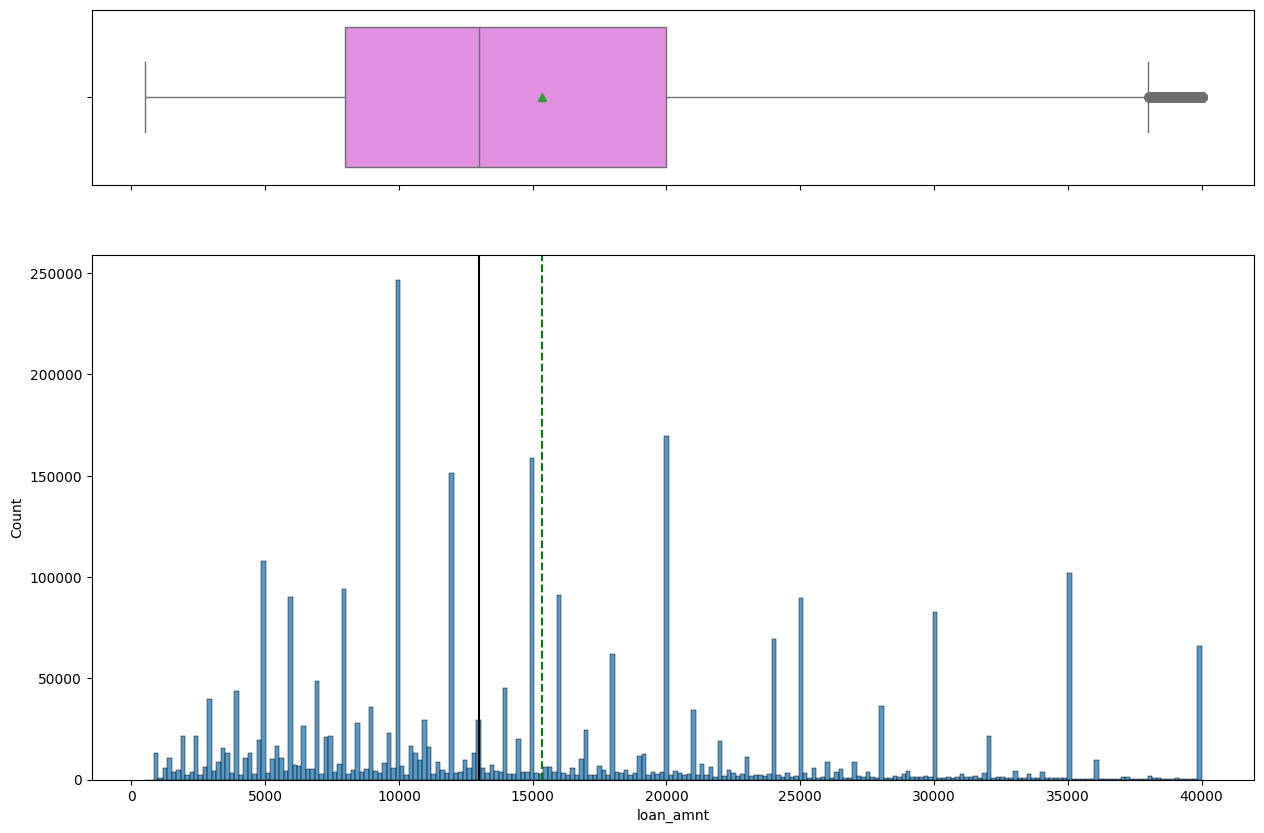

In [ ]:
histogram_boxplot(df, 'loan_amnt')

### Interest Rate

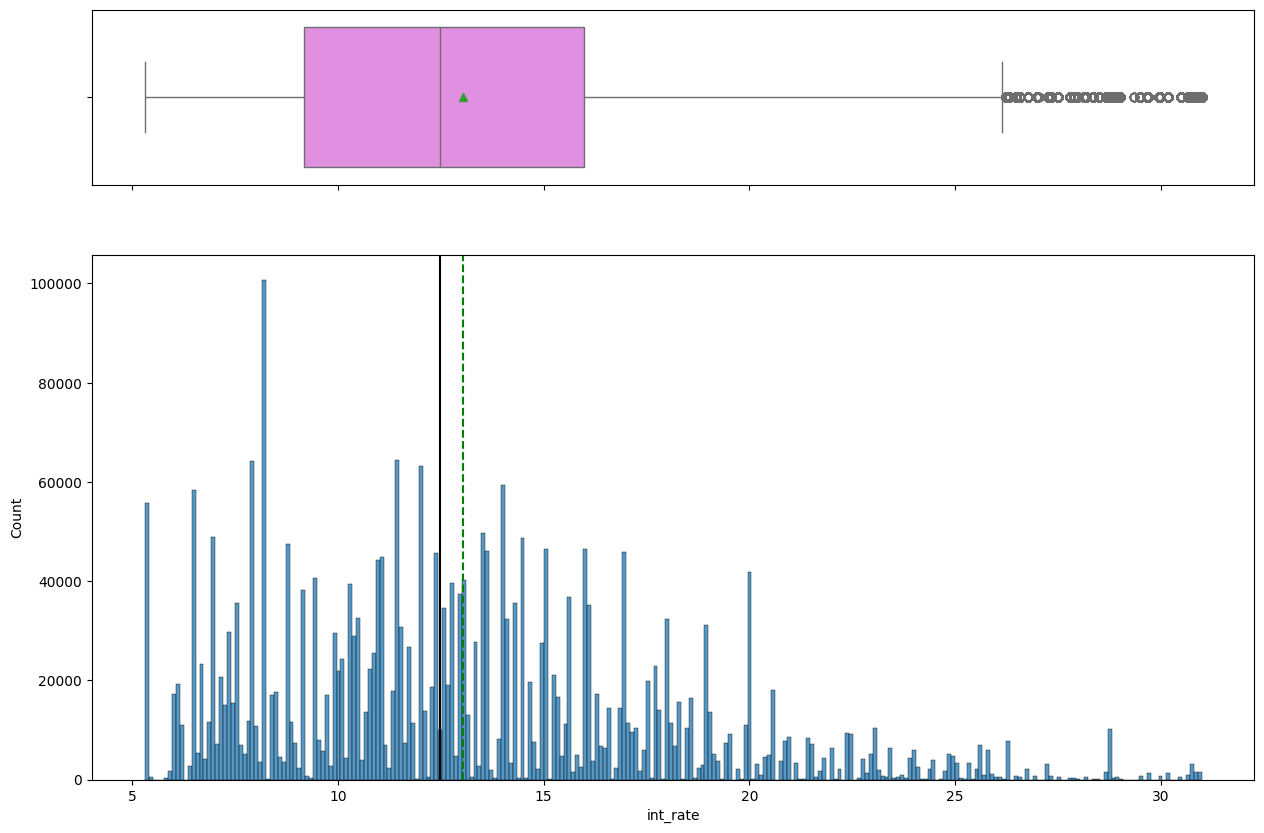

In [ ]:
histogram_boxplot(df, 'int_rate')

### DTI

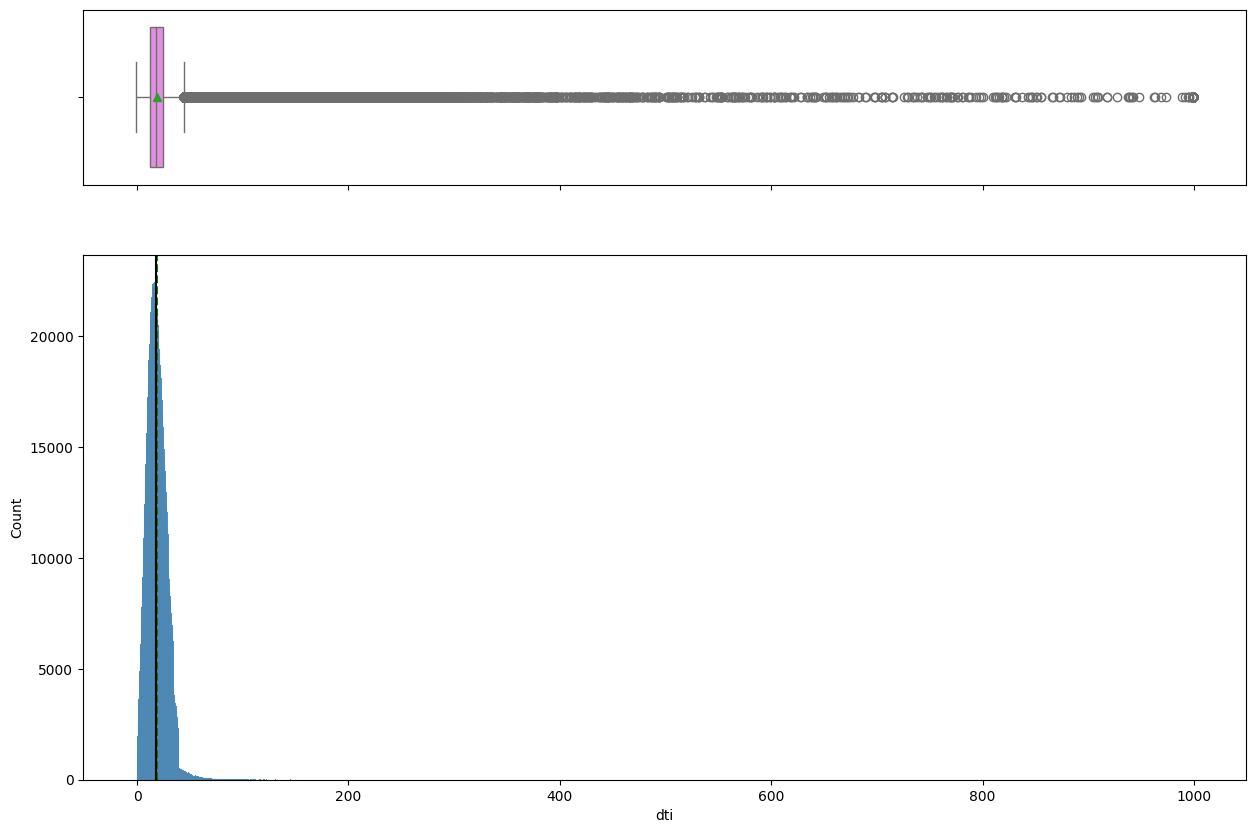

In [ ]:
histogram_boxplot(df, 'dti')

### FICO Range Score

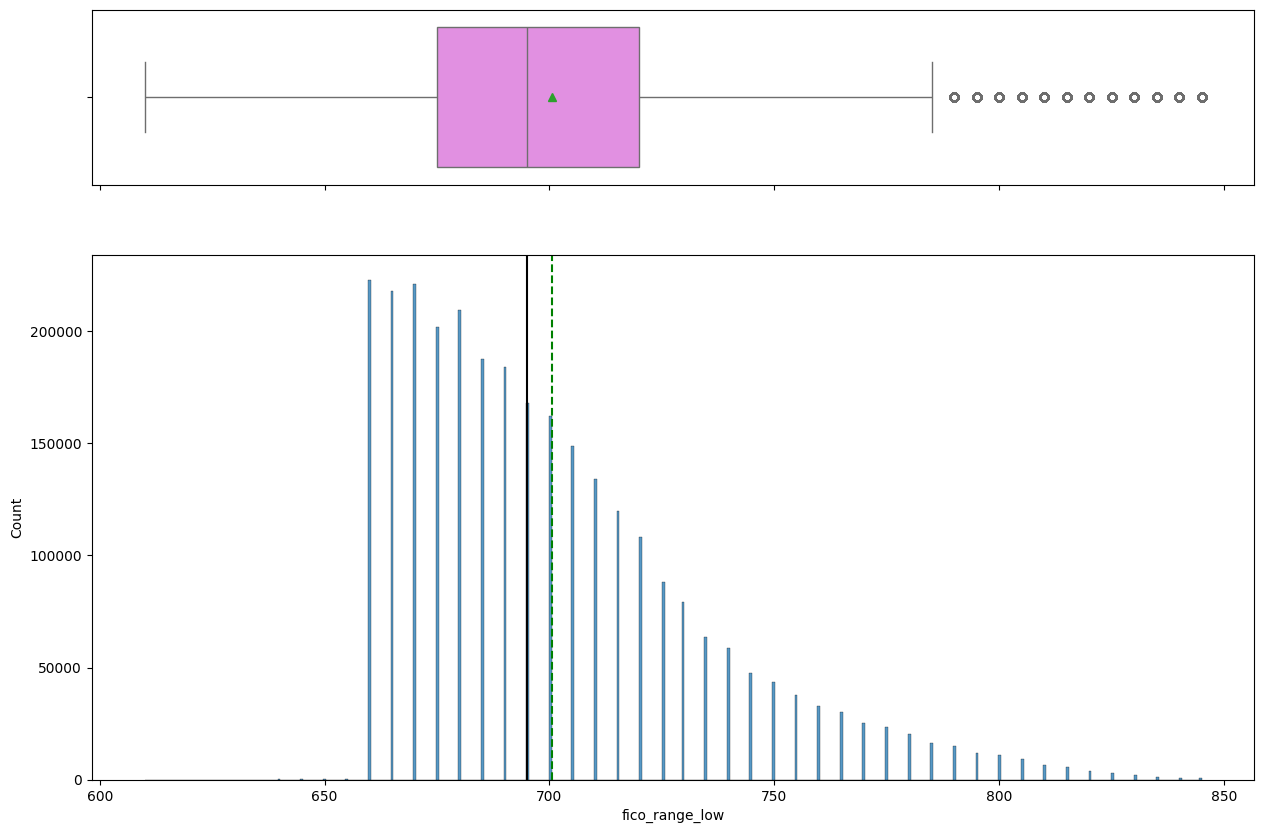

In [ ]:
histogram_boxplot(df, 'fico_range_low')

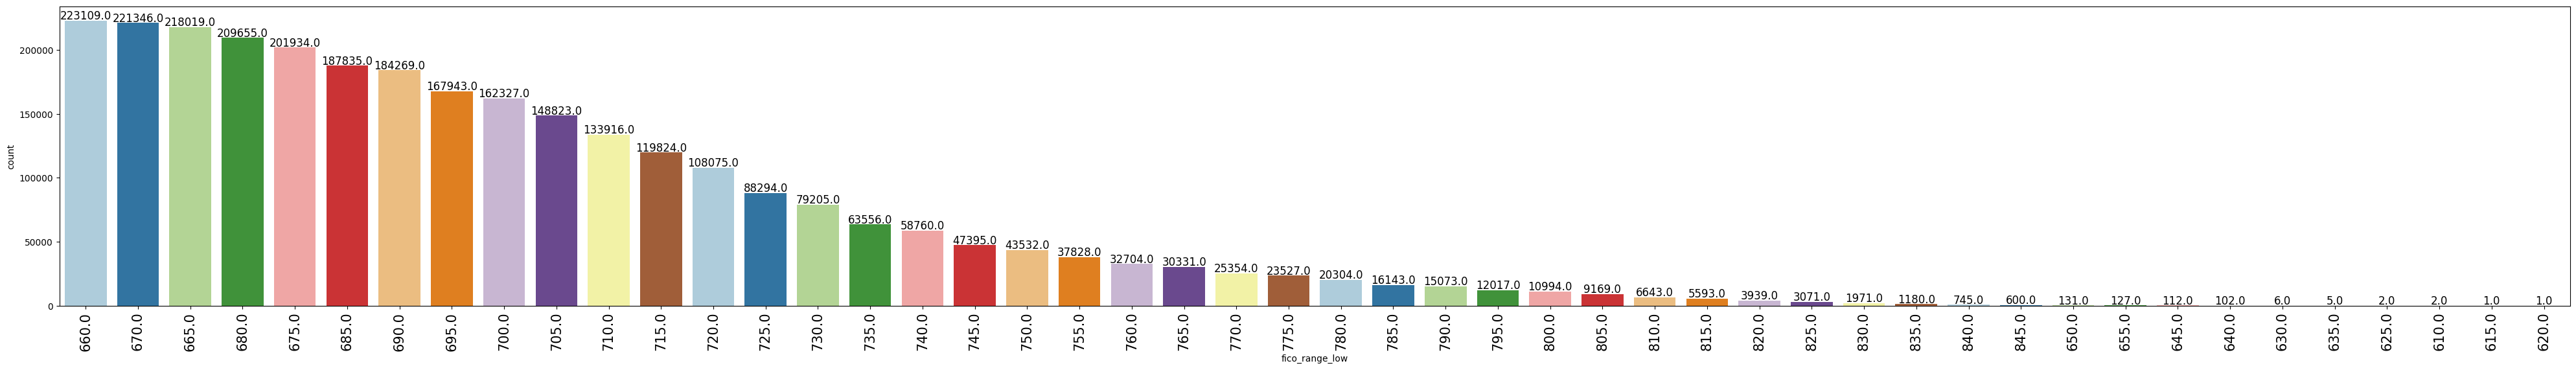

In [ ]:
labeled_barplot(df, 'fico_range_low')

### Term Months

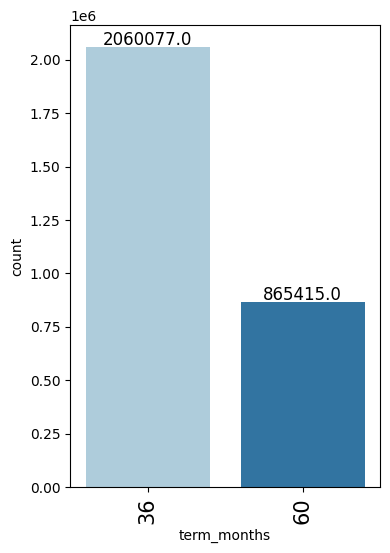

In [ ]:
labeled_barplot(df, 'term_months')

### Is_Bad

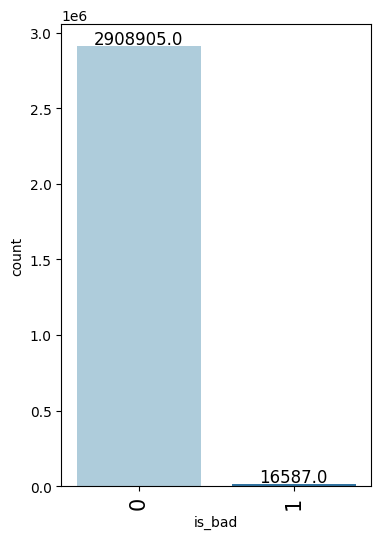

In [ ]:
labeled_barplot(df, 'is_bad')

### Loan Amount Density Overlay

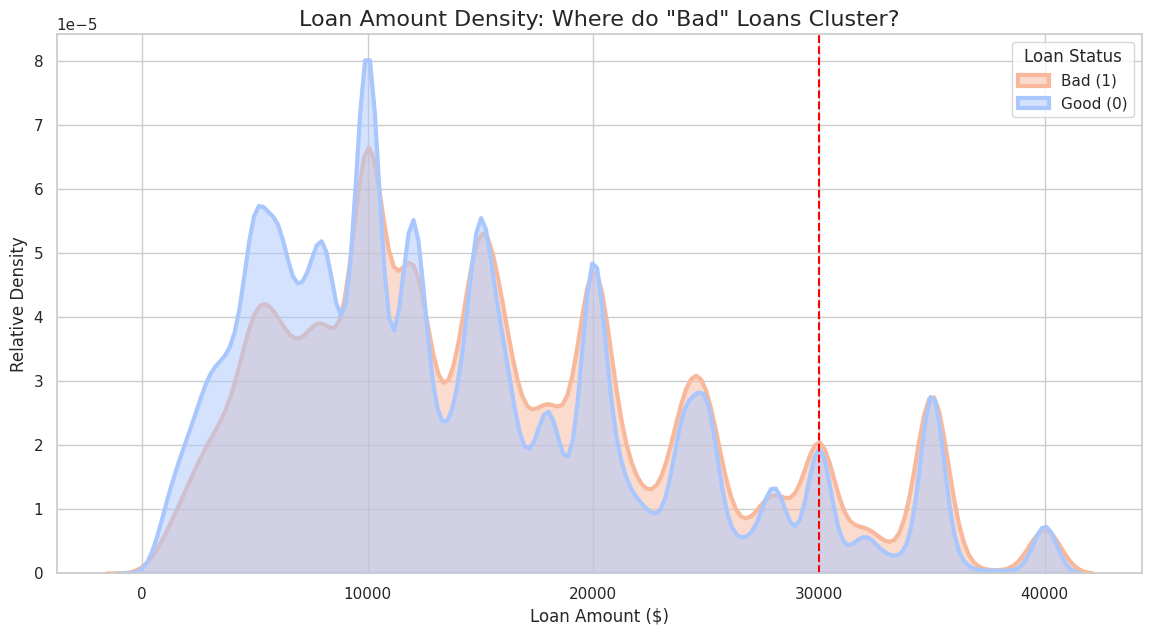

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup the visual style
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# 2. Plot the Density for Good (0) vs Bad (1)
# 'common_norm=False' is critical here; it adjusts the curves to show the
# relative probability within each group regardless of their total count.
sns.kdeplot(data=df_completed, x='loan_amnt', hue='is_bad',
            fill=True, common_norm=False, palette='coolwarm',
            alpha=.5, linewidth=3)

# 3. Add a reference line for your "Whales" ($30k+)
plt.axvline(30000, color='red', linestyle='--', label='Whale Threshold ($30k)')

# 4. Final Formatting for the "Business Case"
plt.title('Loan Amount Density: Where do "Bad" Loans Cluster?', fontsize=16)
plt.xlabel('Loan Amount ($)', fontsize=12)
plt.ylabel('Relative Density', fontsize=12)
plt.legend(title='Loan Status', labels=['Bad (1)', 'Good (0)'], loc='upper right')

plt.show()


* There appears to be alot more good loans in the 10,000 to 20,000 range.
* At 30,000, the bad loans start to slightly outweigh the good loans.

### Calculating Loss severity

In [ ]:
# Create a 'Size' bucket
df_completed['size_category'] = df_completed['loan_amnt'].apply(lambda x: 'Whale (30k+)' if x >= 30000 else 'Standard (<30k)')

# Compare the Default Rate
whale_analysis = df_completed.groupby('size_category').agg({
    'is_bad': 'mean',
    'loan_amnt': 'count'
})

whale_analysis['is_bad'] = (whale_analysis['is_bad'] * 100).round(2)
print(whale_analysis)


                  is_bad  loan_amnt
size_category                      
Standard (<30k) 19.06000    1694433
Whale (30k+)    24.11000     169080


* The bad loans that are greater than 30,000 on average have a default rate of 24.11 % while the standard size of of less than 30,000 have a default rate of 19.06 %.
* This amounts to about a 5% difference between the Whale loans and Standard sized loans.
* There are 169,080 whale loans.



### Checking "Safe Whale" Loans through Risk Layering

In [ ]:
# Filter for just the Whales
whales_only = df_completed[df_completed['size_category'] == 'Whale (30k+)'].copy()

# Create FICO buckets
whales_only['fico_bucket'] = pd.cut(whales_only['fico_range_low'],
                                    bins=[0, 660, 700, 750, 850],
                                    labels=['Subprime (<660)', 'Near-Prime (660-700)', 'Prime (700-750)', 'Super-Prime (750+)'])

# Calculate Default Rate by FICO Bucket
whale_fico_risk = whales_only.groupby('fico_bucket')['is_bad'].mean() * 100
print("Whale Default Rate by FICO Score:")
print(whale_fico_risk.round(2))


Whale Default Rate by FICO Score:
fico_bucket
Subprime (<660)        35.07000
Near-Prime (660-700)   27.85000
Prime (700-750)        19.54000
Super-Prime (750+)     16.63000
Name: is_bad, dtype: float64


* Out of all of the Whale loans above $30,000, the one's that are the safest and have the lowest default rate are the Prime (700-750) and Super-Prime (750+) credit scores with default rates of 19.54% and 16.63% respectively.

* The Subprime Whale loans are the most critical showing a default rate of 35%!

* Near-Prime default rates are almost 30% coming in at 27.85%.

* I would only recommend salvaging the Prime and Super-Prime whale loans because they are below a 20 % default rate.



### Creating Python Script for Running Power BI Report

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925492 entries, 0 to 2925491
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   loan_amnt       float64
 1   int_rate        float64
 2   grade           object 
 3   issue_d         object 
 4   loan_status     object 
 5   dti             float64
 6   fico_range_low  float64
 7   term_months     int64  
 8   is_bad          int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 200.9+ MB


In [ ]:
df['issue_d'].value_counts()

,count
issue_d,
2016-03-01,61992
2019-07-01,50540
2015-10-01,48631
2019-08-01,47554
2018-05-01,46311
2018-10-01,46305
2018-08-01,46079
2019-10-01,46033
2015-07-01,45962


In [ ]:
df_completed['fico_bucket'] = pd.cut(df_completed['fico_range_low'],
                                     bins=[0, 660, 700, 750, 900],
                                     labels=['Subprime', 'Near-Prime', 'Prime', 'Super-Prime'])

# Ensure 'issue_d' is datetime type in df_completed
df_completed['issue_d'] = pd.to_datetime(df_completed['issue_d'], format='%Y-%m-%d', errors='coerce')

# Extract the year from the 'issue_d' datetime column
df_completed['issue_year'] = df_completed['issue_d'].dt.year

# 2. Create the Final Summary for Power BI
# We group by Grade, Term, Year, Size, and FICO to keep the file small but powerful
pbi_final = df_completed.groupby(['grade', 'term_months', 'issue_year', 'size_category', 'fico_bucket']).agg({
    'loan_amnt': ['count', 'sum'],
    'int_rate': 'mean',
    'is_bad': 'mean',
    'dti': 'mean'
}).reset_index()

# Flatten columns
pbi_final.columns = ['Grade', 'Term', 'Year', 'Size', 'FICO_Bucket', 'Loan_Count', 'Total_Volume', 'Avg_Int_Rate', 'Default_Rate', 'Avg_DTI']

# 3. Save to Google Drive
pbi_final.to_csv('/content/drive/My Drive/LendingClub_PBI_Final.csv', index=False)
print("PBI Summary Exported! Ready for Dashboarding.")

PBI Summary Exported! Ready for Dashboarding.
